<a href="https://colab.research.google.com/github/phungnguyen13/phungnghi.github.io/blob/gh-pages/FaceEmotionCNN_try_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving FER Dataset.zip to FER Dataset.zip


In [2]:
import zipfile

with zipfile.ZipFile("FER Dataset.zip", "r") as zip_ref:
    zip_ref.extractall("images")

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

IMG_SIZE = 48
BATCH_SIZE = 64

train_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(30),
    transforms.RandomAffine(
        degrees=0,
        shear=17,
        scale=(0.7, 1.3)
    ),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])

train_dir = "/content/images/images/train"
val_dir   = "/content/images/images/validation"

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir,   transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

NUM_CLASSES = len(train_dataset.classes)

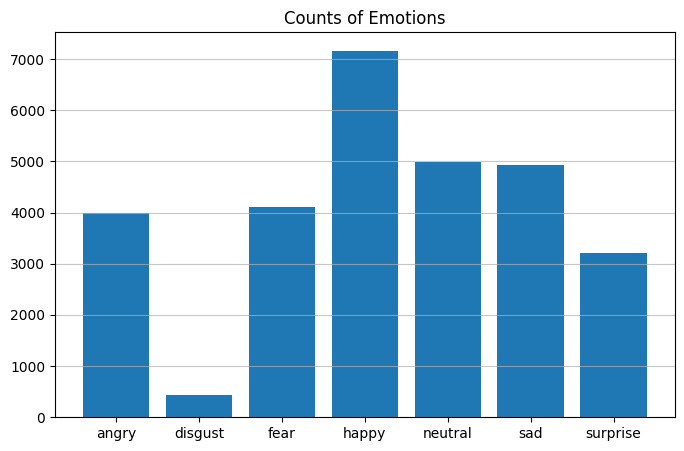

In [4]:
from collections import Counter
import matplotlib.pyplot as plt

dataset = datasets.ImageFolder(train_dir)
labels = [label for _, label in dataset.samples]
num_of_class = Counter(labels)

class_name = dataset.classes
counts = [num_of_class[i] for i in range(len(class_name))]

plt.figure(figsize=(8, 5))
plt.bar(class_name, counts)
plt.title('Counts of Emotions')
plt.grid(axis='y', alpha=0.7)
plt.show()

In [10]:
import torch.nn as nn
import torch.nn.functional as F

class FaceEmotionCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        # Block 1
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=0, stride=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=0, stride=1)
        self.pool1 = nn.MaxPool2d(2)
        self.drop1 = nn.Dropout(p=0.1)

        # Block 2
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=0, stride=1)
        self.pool2 = nn.MaxPool2d(2)
        self.drop2 = nn.Dropout(p=0.1)

        # Block 3
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=0, stride=1)
        self.pool3 = nn.MaxPool2d(2)
        self.drop3 = nn.Dropout(p=0.1)

        self.fc1 = nn.Linear(256*4*4, 512)
        self.drop_fc = nn.Dropout(p=0.2)
        self.fc_out = nn.Linear(512, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)
        x = self.drop1(x)

        x = F.relu(self.conv3(x))
        x = self.pool2(x)
        x = self.drop2(x)

        x = F.relu(self.conv4(x))
        x = self.pool3(x)
        x = self.drop3(x)

        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.drop_fc(x)
        x = self.fc_out(x)
        return x

In [11]:
import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = FaceEmotionCNN(num_classes=NUM_CLASSES).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
train_acc_history = []
val_acc_history = []

def run_epoch(loader, train=True):
    model.train(train)
    total, correct, total_loss = 0, 0, 0.0
    for imgs, labels in tqdm.tqdm(loader, leave=False):
        imgs, labels = imgs.to(device), labels.to(device)
        if train:
            optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        if train:
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        preds = logits.argmax(1)
        correct += (preds == labels).sum().item()
        total += imgs.size(0)
    return total_loss/total, correct/total

EPOCHS = 100
best_val = 0.0
for epoch in range(1, EPOCHS+1):
    train_loss, train_acc = run_epoch(train_loader, train=True)
    val_loss, val_acc = run_epoch(val_loader, train=False)

    train_acc_history.append(train_acc)
    val_acc_history.append(val_acc)

    print(f"Epoch {epoch:02d} | Train_acc {train_acc:.4f} | Train_loss {train_loss:.4f} | Val_acc {val_acc:.3f} | Val_loss {val_loss:.4f}")
    if val_acc > best_val:
        best_val = val_acc
        torch.save(model.state_dict(), "face_emotion_detection.pt")


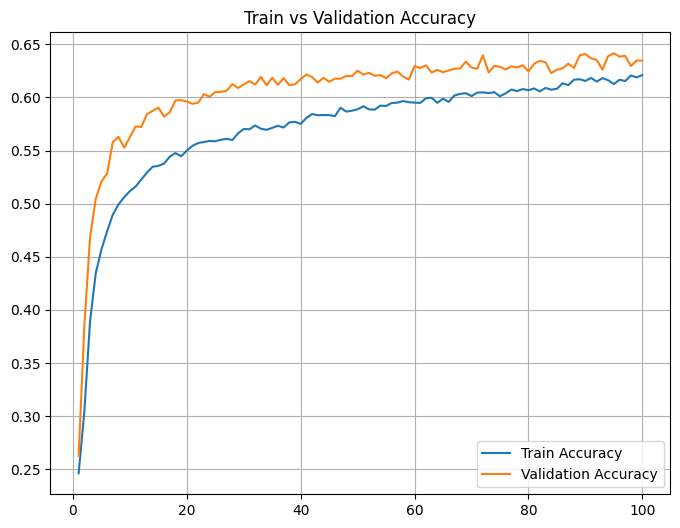

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(range(1, EPOCHS+1), train_acc_history, label='Train Accuracy')
plt.plot(range(1, EPOCHS+1), val_acc_history, label='Validation Accuracy')
plt.title('Train vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()